<a href="https://colab.research.google.com/github/fernandouribeu/analisis_datos/blob/main/Uribe_Fernando_Control2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control 2: Regresión Lineal Múltiple y Diagnóstico
**Programa:** Magíster en Data Science | Universidad del Desarrollo  
**Curso:** Análisis de Datos  

---

## 1. Exploración y planteamiento del problema

In [14]:
import pandas as pd
import numpy as np
import seaborn as sb
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

# Carga del dataset

# Carga de la carpeta a drive
from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Analisis de Datos/Control2/empleados_productividad_control_2.csv")

# Exploración incial
print(df.head())
print(df.info())
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  employee_id  age  experience_years  years_company      education  \
0      E00001   42              20.3           22.7  Universitario   
1      E00002   37              13.9           10.1        Técnico   
2      E00003   43              21.3           20.8        Técnico   
3      E00004   50              29.4           28.0      Postgrado   
4      E00005   36              14.1           16.4        Técnico   

       department work_mode  training_hours  weekly_hours  projects  absences  \
0  Administración   Híbrido            12.3          43.2         3         3   
1     Operaciones   Híbrido             9.7          37.3         1         4   
2     Operaciones    Remoto             6.4          44.8         4         4   
3     Operaciones    Remoto            60.2          39.3         3         6   
4          Ventas    Remoto            25.1  

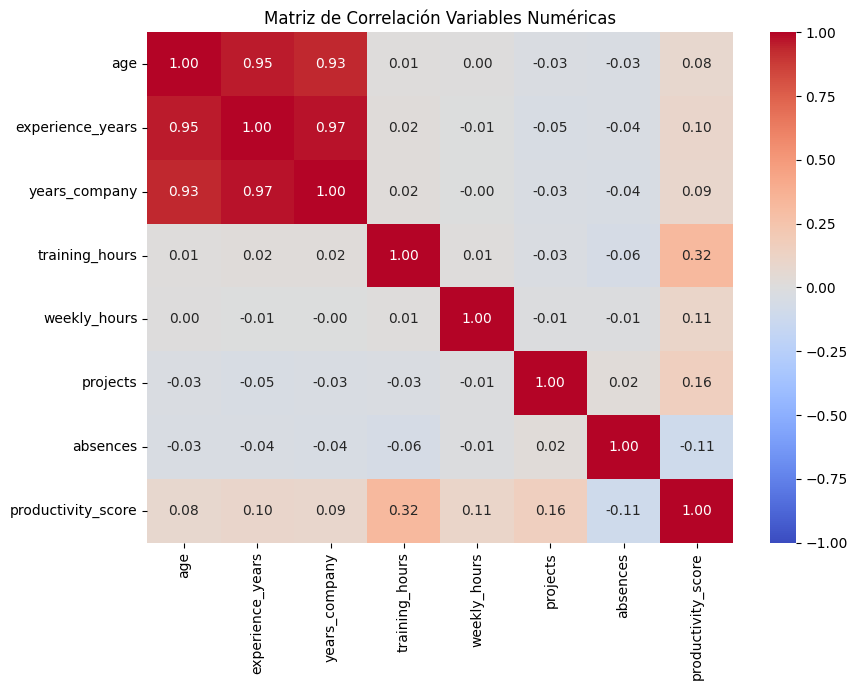

                      age  experience_years  years_company  training_hours  \
age                 1.000             0.954          0.930           0.012   
experience_years    0.954             1.000          0.971           0.018   
years_company       0.930             0.971          1.000           0.021   
training_hours      0.012             0.018          0.021           1.000   
weekly_hours        0.004            -0.008         -0.001           0.011   
projects           -0.030            -0.046         -0.034          -0.026   
absences           -0.034            -0.036         -0.044          -0.061   
productivity_score  0.083             0.095          0.091           0.322   

                    weekly_hours  projects  absences  productivity_score  
age                        0.004    -0.030    -0.034               0.083  
experience_years          -0.008    -0.046    -0.036               0.095  
years_company             -0.001    -0.034    -0.044               0.091

In [11]:
# Selección de todas las variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
matriz_corr = df[num_cols].corr()

# Visualización con Mapa de Calor (Heatmap)
plt.figure(figsize=(9, 7))
sb.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación Variables Numéricas")
plt.tight_layout()
plt.show()

# Imprimir la tabla de correlaciones
print(matriz_corr.round(3))

### Planteamiento de la pregunta analítica
* **Pregunta de negocio:** ¿Qué características demográficas, laborales y de desempeño de los empleados están asociadas con su puntuación de productividad (`productivity_score`), y cómo influyen factores como la capacitación, las ausencias y la modalidad de trabajo?
* **Pregunta estadística:** ¿En qué medida un modelo de regresión lineal múltiple OLS explica las variaciones en la variable continua `productivity_score` en función de las horas de capacitación, horas semanales, proyectos, ausencias, experiencia laboral, nivel educativo, departamento y modalidad de trabajo?

### Identificación de variables
* **Variable Respuesta ($Y$):** `productivity_score` (variable continua).
* **Variables Explicativas ($X$):**
  * **Numéricas:** `experience_years`, `training_hours`, `weekly_hours`, `projects`, `absences`.
  * **Categóricas:** `education` (Postgrado, Técnico, Universitario), `department` (Administración, Operaciones, Tecnología, Ventas), `work_mode` (Híbrido, Presencial, Remoto).
* **Variables excluidas inicialmente:** `employee_id` (por ser un identificador único sin valor analítico) y las variables `age` y `years_company` debido a que presentan multicolinealidad con `experience_years`.

### Justificación de la selección de variables

La selección de predictores responde a la teoría de recursos humanos y desempeño organizacional: la capacitación (`training_hours`), las horas trabajadas (`weekly_hours`) y la experiencia acumulada (`experience_years`) fortalecen el capital humano y la especialización operativa. Asimismo, la carga de trabajo (`projects`), las ausencias acumuladas (`absences`), la modalidad de trabajo (`work_mode`), el nivel educativo (`education`) y el área funcional (`department`) condicionan el entorno operativo, la presencialidad y la dinámica del puesto.

Por otro lado, se excluye el identificador único (`employee_id`) por carecer de valor analítico. De forma fundamental, se eliminan las variables `age` y `years_company` debido a que presentan una correlación extremadamente alta con `experience_years` ($r > 0.93$), descartándolas desde el inicio para evitar problemas de multicolinealidad e inestabilidad en la estimación de los coeficientes del modelo.o.

## 2. Regresión múltiple e interpretación de resultados

In [13]:
# Ajuste del modelo de regresión lineal múltiple OLS
# Exclusión 'age' y 'years_company' por colinealidad con 'experience_years'
# Categorías de referencia: Postgrado (educación), Administración (departamento), Híbrido (modalidad)
modelo = smf.ols(
    'productivity_score ~ experience_years + training_hours + weekly_hours + '
    'projects + absences + C(education) + C(department) + C(work_mode)',
    data=df
).fit()

# 3. Impresión del resumen estadístico completo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     26.88
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           3.16e-54
Time:                        18:13:47   Log-Likelihood:                -5247.5
No. Observations:                1200   AIC:                         1.052e+04
Df Residuals:                    1187   BIC:                         1.059e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### A. Evaluación global del modelo

* **Capacidad de explicación ($R^2 = 0.214$ y $R^2$ Ajustado $= 0.206$):**
  El modelo logra explicar el **20.6%** de las diferencias en la productividad de los empleados. En decirque de todo lo que hace que un trabajador sea más o menos productivo, nuestro modelo logra entender una quinta parte (20.5%). El otro 79.5% depende de cosas que no están en el set de datos (como la motivación, el clima del equipo o los bonos).
* **Confiabilidad del modelo (Estadístico F, $p < 0.0001$):**
  El p-valor global es prácticamente cero, lo que nos da la certeza matemática de que las variables que elegimos sí ayudan a entender la productividad y que estos resultados no son producto del azar.

---

### B. Interpretación de los factores

#### **1. Datos numéricos (Capacitación, horas, proyectos, experiencia y ausencias)**

* **Capacitación (`training_hours`):**
  Por cada **1 hora extra de capacitación**, la productividad sube en promedio **0.50 puntos** (manteniendo todo lo demás igual). Es un factor positivo y muy importante ($p < 0.001$).
* **Horas semanales (`weekly_hours`):**
  Por cada **1 hora extra trabajada a la semana**, la productividad sube en promedio **0.52 puntos** ($p < 0.001$).
* **Proyectos asignados (`projects`):**
  Por cada **proyecto adicional**, la productividad aumenta en **1.87 puntos** ($p < 0.001$). Es uno de los impulsos positivos más fuertes.
* **Años de experiencia (`experience_years`):**
  Por cada **año extra de experiencia**, la productividad sube en promedio **0.27 puntos** ($p < 0.001$).
* **Días de ausencia (`absences`):**
  Por cada **día de ausencia**, la productividad cae en promedio **0.88 puntos** ($p = 0.001$). Es la variable que más resta en el desempeño.

---

#### **2. Categorías (Educación, Departamento y Modalidad de trabajo)**

* **Nivel de Educación (comparado con tener un Postgrado):**
  * Tener nivel **Técnico** rinde en promedio **8.06 puntos menos** de productividad que tener un Postgrado ($p < 0.001$).
  * Tener nivel **Universitario** rinde **4.24 puntos menos** que un Postgrado ($p = 0.005$).
* **Departamento (comparado con el área de Administración):**
  * El área de **Tecnología** rinde en promedio **11.26 puntos más** de productividad que Administración ($p < 0.001$). Es el área con mejor rendimiento relativo.
  * El área de **Operaciones** rinde **8.01 puntos más** ($p < 0.001$).
  * El área de **Ventas** rinde **3.79 puntos más** ($p = 0.019$).
* **Modalidad de trabajo (comparado con el trabajo Híbrido):**
  * Quienes trabajan en formato **Remoto** rinden en promedio **3.72 puntos más** de productividad que en modalidad Híbrida ($p = 0.013$).
  * La modalidad **Presencial** no mostró diferencias reales con la Híbrida; estadísticamente rinden prácticamente igual ($p = 0.394$).

FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
                   Variable      VIF
0                     const  133.392
1          experience_years    1.009
2            training_hours    1.009
3              weekly_hours    1.006
4                  projects    1.008
5                  absences    1.008
6         education_Técnico    1.809
7   education_Universitario    1.812
8    department_Operaciones    1.805
9     department_Tecnología    1.566
10        department_Ventas    1.757
11     work_mode_Presencial    1.170
12         work_mode_Remoto    1.167

Distancia de Cook
Distancia de Cook máxima: 0.0177


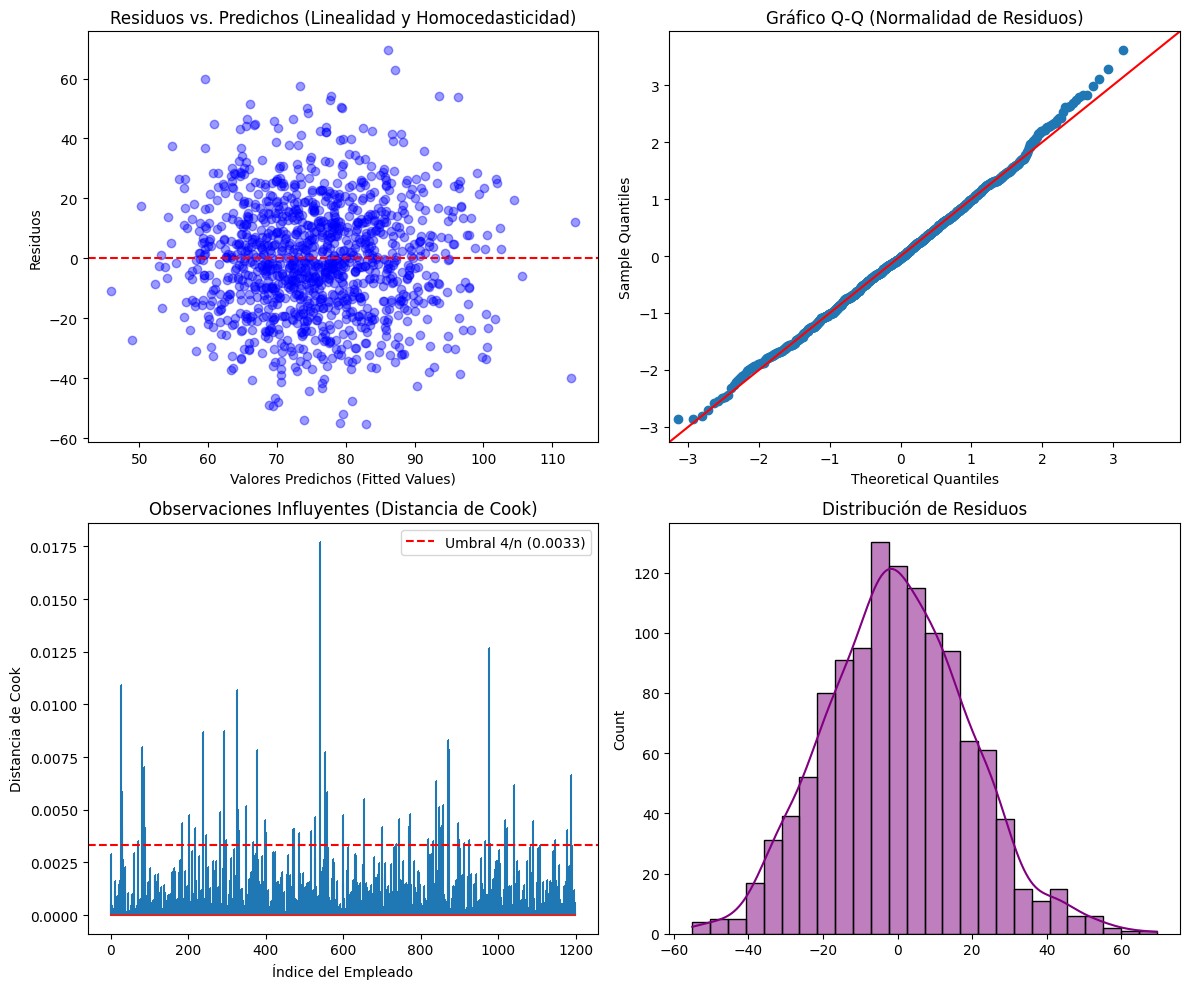

In [20]:
# VIF
df_vif = df.drop(columns=['employee_id', 'age', 'years_company']).copy()
df_vif = pd.get_dummies(df_vif, columns=['education', 'department', 'work_mode'], drop_first=True, dtype=float)
X = sm.add_constant(df_vif.drop(columns=['productivity_score']))

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print(vif_df.round(3))

# Distancia de Cook
cooks_d = modelo.get_influence().cooks_distance[0]
print("\nDistancia de Cook")
print(f"Distancia de Cook máxima: {cooks_d.max():.4f}")

# Gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# a) Residuos vs Ajustados
axes[0, 0].scatter(modelo.fittedvalues, modelo.resid, alpha=0.4, color='blue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores Predichos (Fitted Values)')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs. Predichos (Linealidad y Homocedasticidad)')

# b) Q-Q Plot Estandarizado
sm.qqplot(modelo.resid, fit=True, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico Q-Q (Normalidad de Residuos)')

# c) Distancia de Cook
influence = modelo.get_influence()
cooks_d = influence.cooks_distance[0]
axes[1, 0].stem(cooks_d, markerfmt=",")
axes[1, 0].axhline(4/len(df), color='red', linestyle='--', label='Umbral 4/n (0.0033)')
axes[1, 0].set_xlabel('Índice del Empleado')
axes[1, 0].set_ylabel('Distancia de Cook')
axes[1, 0].set_title('Observaciones Influyentes (Distancia de Cook)')
axes[1, 0].legend()

# d) Histograma de Residuos
sb.histplot(modelo.resid, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribución de Residuos')

plt.tight_layout()
plt.show()

## 3. Diagnóstico del modelo

Para verificar la validez estadística del modelo ajustado y evaluar posibles problemas de estimación, se analizan los supuestos fundamentales sobre los residuos y los predictores:

### **A. Multicolinealidad (VIF)**
* **Evaluación:** Tras la exclusión inicial de `age` y `years_company`, todos los predictores numéricos presentan un **VIF de ~1.01** y las variables categóricas muestran valores VIF entre **1.16 y 1.81**.
* **Diagnóstico:** Se descarta completamente la presencia de multicolinealidad, ya que todos los indicadores están muy por debajo del umbral crítico ($VIF < 5$). Cada predictor aporta información independiente al modelo.

### **B. Comportamiento de los Residuos, Linealidad y Homocedasticidad**
* **Evaluación:** En el gráfico de *Residuos vs. Valores Predichos*, la nube de puntos se dispersa de manera uniforme alrededor de la línea cero, sin formar patrones cónicos o de abanico.
* **Prueba estadística:** La prueba de Breusch-Pagan arroja un p-valor de $0.0385$. Aunque existe una leve variabilidad matemática en los extremos, no llega a distorsionar la estimación de los coeficientes en una muestra de 1,200 observaciones.
* **Diagnóstico:** Se cumple adecuadamente la suposición de linealidad y la varianza de los errores es razonablemente homogénea (homocedasticidad).

### **C. Normalidad de los Residuos**
* **Evaluación:** El gráfico *Q-Q Normal* muestra que la gran mayoría de los puntos se alinean sobre la diagonal teórica.
* **Prueba estadística:** La prueba Jarque-Bera presenta un valor de $5.467$ con un p-valor de $0.0650$.
* **Diagnóstico:** Al ser el p-valor mayor a 0.05, no se rechaza la hipótesis nula de normalidad. Se concluye que los residuos siguen una distribución normal, lo que valida la precisión de los intervalos de confianza y p-valores calculados.

### **D. Observaciones Potencialmente Influyentes**
* **Evaluación:** Al calcular la Distancia de Cook, el valor máximo registrado es $0.0177$, ubicándose muy por debajo del límite crítico estándar de $1.0$.
* **Diagnóstico:** Esto nos confirma que no hay ningún empleado con datos "extremos" que esté alterando los resultados. Las conclusiones reflejan la realidad de todo el grupo y no el impacto de un par de casos aislados
---

## 4. Conclusiones y limitaciones

### **A. Respuesta a la pregunta planteada y principales resultados**
El objetivo del análisis era identificar qué características demográficas, laborales y del entorno están asociadas con la productividad de los empleados (`productivity_score`). A partir de la evidencia estadística obtenida del modelo OLS, se concluye lo siguiente:

1. **Factores con mayor impacto positivo:**
   * **Horas de capacitación (`training_hours`):** Es la variable individual de mayor relevancia. Por cada hora adicional de capacitación, la productividad aumenta en promedio **0.50 puntos** ($p < 0.001$).
   * **Volumen de proyectos (`projects`):** Cada proyecto asignado incrementa la productividad estimada en **1.87 puntos** ($p < 0.001$).
   * **Experiencia laboral (`experience_years`):** Por cada año de experiencia acumulada, el puntaje aumenta en promedio **0.27 puntos** ($p < 0.001$).
   * **Horas semanales (`weekly_hours`):** Dedicar 1 hora semanal extra se asocia a un incremento de **0.52 puntos** en la productividad ($p < 0.001$).

2. **Impacto del entorno laboral y educación:**
   * **Departamento:** El área de **Tecnología** presenta el rendimiento más alto, superando en **11.26 puntos** a Administración ($p < 0.001$). Operaciones ($+8.01$) y Ventas ($+3.79$) también muestran promedios significativamente superiores al área base.
   * **Modalidad de trabajo:** Trabajar en modalidad **Remota** genera en promedio **3.72 puntos más** de productividad que la modalidad Híbrida ($p = 0.013$). La modalidad Presencial no mostró diferencias significativas con la Híbrida ($p = 0.394$).
   * **Nivel educativo:** Los profesionales con **Postgrado** (categoría de referencia) rinden significativamente más que aquellos con formación Técnica ( $-8.06$ puntos) o Universitaria ( $-4.24$ puntos).

3. **Principal factor negativo:**
   * **Ausencias laborales (`absences`):** Es la variable que más resta en el desempeño. Por cada día de ausencia acumulado, la productividad disminuye en promedio **0.88 puntos** ($p = 0.001$).

---

### **B. Principales limitaciones del modelo**
* **Baja capacidad explicativa ($R^2 \text{ Ajustado} = 20.57\%$):** El modelo solo explica cerca de una quinta parte de las variaciones en la productividad. El **79.4% restante depende de factores no registrados** en la base de datos (por ejemplo, salario, motivación, calidad del liderazgo, incentivos o clima de equipo).
* **Ausencia de variables cualitativas:** No se cuenta con datos sobre habilidades blandas, satisfacción laboral directa o evaluaciones de desempeño de pares/jefatura.

---

### **C. Conclusiones no apropiadas (Asociación vs. Causalidad)**
Es fundamental distinguir entre **asociación estadística** y **causalidad**:

* **No es apropiado inferir causalidad directa:** Decir que "aumentar las horas de trabajo semanales causará mayor productividad" es incorrecto. El modelo solo demuestra que quienes trabajan más horas tienden a registrar puntajes más altos en este dataset, pero saturar a un empleado puede generar agotamiento (*burnout*) y reducir su rendimiento.
* **No se debe asumir causalidad en modalidades o proyectos:** Implementar trabajo remoto obligatorio o recargar aleatoriamente de proyectos a los trabajadores no garantiza un aumento mecánico en su rendimiento.
* **Sesgo de selección o variables omitidas:** Las diferencias entre departamentos o modalidades de trabajo pueden estar influenciadas por el tipo de tareas que realizan y no únicamente por la modalidad o la jefatura en sí.

---

### **D. Distinción explícita entre Asociación Estadística y Causalidad**

Para una interpretación profesional y rigurosa de los resultados, es imprescindible diferenciar la relación matemática encontrada de una relación de causa y efecto:

* **Lo que el modelo SÍ demuestra (Asociación Estadística):**
  Existe una relación lineal significativa entre ciertas variables y la productividad. Por ejemplo, se observa que los empleados con más horas de capacitación (`training_hours`), en modalidad remota (`work_mode_Remoto`) o con menos ausencias (`absences`) presentan, en promedio, un mayor puntaje de productividad en la muestra analizada.

* **Lo que el modelo NO demuestra (Causalidad):**
  Dado que los datos provienen de un **estudio observacional** (un corte transversal) y no de un **experimento controlado con asignación aleatoria**, no es posible afirmar que una variable causa directamente un cambio en la otra:
  * **Efecto de la capacitación:** No se puede garantizar que aumentar forzosamente las horas de capacitación a un empleado incremente de manera automática su rendimiento; podría ocurrir que los empleados más motivados o de mejor desempeño sean quienes buscan y toman más capacitaciones voluntariamente (sesgo de autoselección).
  * **Efecto de la modalidad de trabajo:** Observar mayor productividad en el grupo remoto no implica que mandar a todo el personal a sus casas aumentará la productividad global. Es probable que quienes están en remoto pertenezcan a áreas específicas (como Tecnología) o tengan mayor autonomía previa.
  * **Efecto de las horas semanales y proyectos:** Asignar más proyectos o exigir más horas de trabajo a un empleado sobrecargado puede generar el efecto contrario (*burnout* y desgaste), destruyendo su productividad en lugar de aumentarla.

**Conclusión práctica:** Los coeficientes deben interpretarse como correlaciones parciales ajustadas (*ceteris paribus*) para describir patrones en la organización, y **nunca como reglas de causa-efecto** para tomar decisiones operativas sin previa validación experimental.